# Sistemas Dinámicos: Hegselmann-Krause
**Módulo 4 — Sistemas Dinámicos y Solución Numérica de EDOs**

**Programación Científica 2026-1 · Universidad Nacional de Colombia**  
mbastidaso@unal.edu.co

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

Este notebook define y visualiza un modelo de dinámica social:

1. **Hegselmann-Krause (H-K)**: polarización de opiniones bajo un umbral de confianza $\varepsilon$.


In [5]:
# ── Instalación de LaTeX para renderizado tipográfico (descomentar en Colab) ──
!sudo apt-get update -qq
!sudo apt-get install -qq texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# ── Configuración global de estilo matplotlib ────────────────────────────────
# Renderiza etiquetas con LaTeX y fuente serif (Computer Modern), igual que
# los slides de la clase. Mejora la legibilidad en figuras publicables.
plt.rcParams.update({
    "text.usetex"        : True,
    "font.family"        : "serif",
    "font.serif"         : ["Computer Modern Roman"],
    "font.size"          : 14,

    # Ejes y ticks
    "axes.labelsize"     : 16,
    "axes.titlesize"     : 18,
    "xtick.labelsize"    : 12,
    "ytick.labelsize"    : 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",

    # Grilla
    "grid.color"         : "gray",
    "grid.linewidth"     : 0.3,
    "grid.alpha"         : 0.3,
    "grid.linestyle"     : "--",

    # Estética general
    "figure.dpi"         : 120,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "savefig.bbox"       : "tight",
    "savefig.dpi"        : 300,
})
print("Configuración OK")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 56.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-droid-fallback.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-fonts-droid-fallback_1%3a6.0.1r16-1.1build1_all.deb ...
Unpacking fonts-droid-fallback (1:6.0.1r16-1.1build1) ...
Selecting previously unselected package fonts-lato.
Preparing to unpack .../01-fonts-

---
## Parte 1 — Modelo de Hegselmann-Krause (H-K)

El modelo H-K captura cómo los agentes actualizan sus opiniones
$x_i(t) \in [-1, 1]$ interactuando **solo** con quienes tienen opiniones cercanas:

$$
\dot{x}_i(t) =
\frac{1}{|\mathcal{N}_i(t)|}
\sum_{j \in \mathcal{N}_i(t)} \!\bigl(x_j(t) - x_i(t)\bigr),
\qquad
\mathcal{N}_i(t) = \{j : |x_j(t) - x_i(t)| < \varepsilon\}.
$$

El umbral $\varepsilon > 0$ modela el **radio de confianza**:
si la diferencia de opiniones supera $\varepsilon$, el agente $i$ ignora al agente $j$.


### 1.1 Campo vectorial para $N=2$ agentes

Con dos agentes el espacio de estados es $[-1,1]^2$.
El campo vectorial $(\dot{x}_1, \dot{x}_2)$ muestra cómo evoluciona
el par de opiniones en cada punto del plano.

La **banda azul** señala la región de interacción $|x_2 - x_1| < \varepsilon$.
Fuera de ella el campo es cero: no hay cambio de opinión.


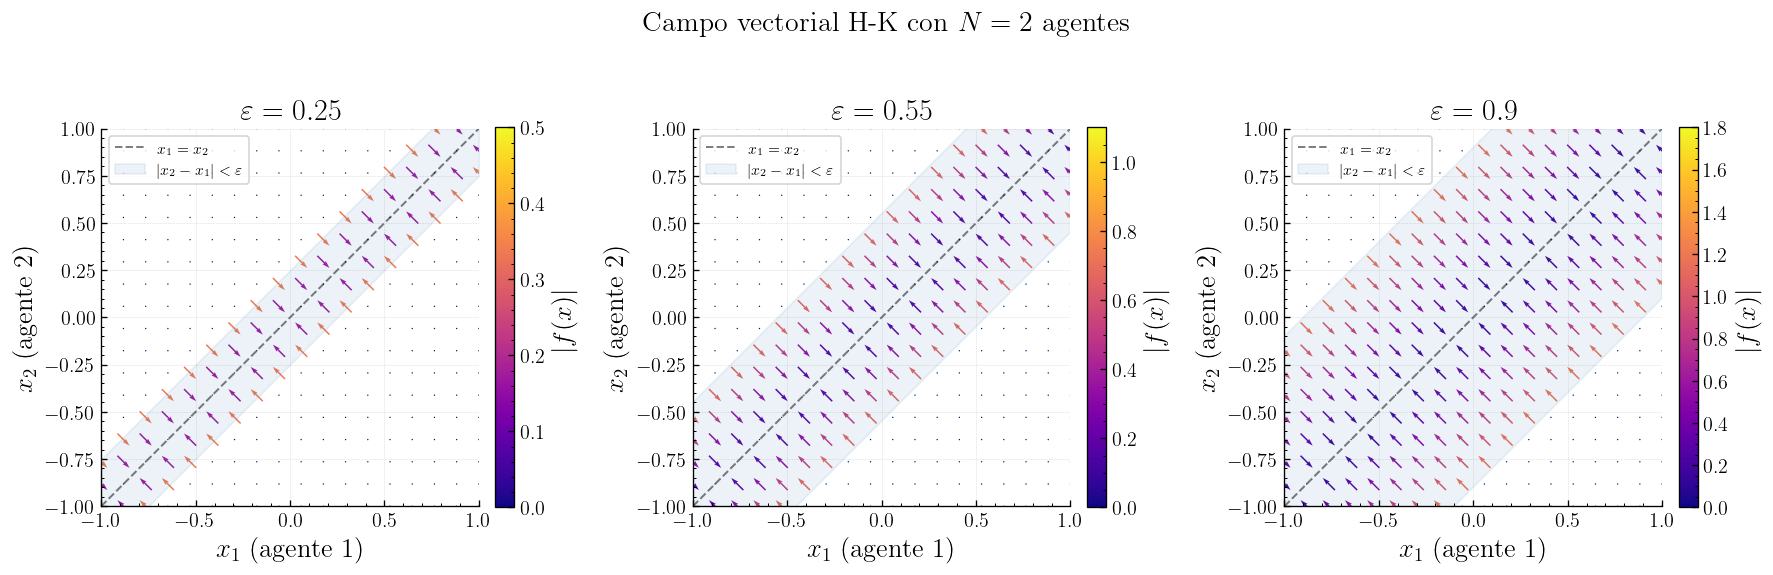

In [6]:
# ── Campo vectorial H-K para N=2 agentes ────────────────────────────────────
# Se visualiza para tres umbrales representativos:
#   ε = 0.25 → muy restrictivo: fragmentación total
#   ε = 0.55 → intermedio: posible polarización en dos clusters
#   ε = 0.90 → permisivo: consenso global

eps_vals = [0.25, 0.55, 0.90]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, eps in zip(axes, eps_vals):
    # Malla de puntos en el espacio de estados [−1, 1]²
    x1, x2 = np.meshgrid(np.linspace(-1, 1, 18), np.linspace(-1, 1, 18))

    # Diferencia de opiniones entre los dos agentes
    diff = x2 - x1

    # Máscara: True donde los agentes están dentro del radio de confianza
    inside = np.abs(diff) < eps

    # Campo vectorial: cada agente se mueve hacia el otro si están dentro del radio
    # Fuera del radio: no hay interacción (campo = 0)
    dx1 = np.where(inside,  diff, 0.0)   # ẋ₁ = (x₂ − x₁) si |diff| < ε, else 0
    dx2 = np.where(inside, -diff, 0.0)   # ẋ₂ = (x₁ − x₂) si |diff| < ε, else 0

    # Magnitud del campo para el colormap
    mag = np.sqrt(dx1**2 + dx2**2)
    nf  = np.where(mag > 0, mag, 1.0)    # denominador seguro (evitar 0/0)

    # Quiver: flechas normalizadas coloreadas por magnitud
    qv = ax.quiver(x1, x2, dx1/nf, dx2/nf, mag,
                   cmap="plasma", scale=22, width=0.004, pivot="mid",
                   clim=[0, 2*eps])
    plt.colorbar(qv, ax=ax, label=r"$|f(x)|$", fraction=0.046, pad=0.04)

    # Diagonal x₁ = x₂: todo punto sobre esta recta es un estado de consenso
    ax.plot([-1, 1], [-1, 1], "k--", lw=1.2, alpha=0.5, label=r"$x_1 = x_2$")

    # Banda de confianza: zona donde los dos agentes interactúan
    ax.fill_between([-1, 1], [-1 - eps, 1 - eps], [-1 + eps, 1 + eps],
                    alpha=0.10, color="steelblue",
                    label=r"$|x_2 - x_1| < \varepsilon$")

    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
    ax.set_xlabel(r"$x_1$ (agente 1)")
    ax.set_ylabel(r"$x_2$ (agente 2)")
    ax.set_title(fr"$\varepsilon = {eps}$")
    ax.set_aspect("equal")
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(True)

plt.suptitle(r"Campo vectorial H-K con $N=2$ agentes")
plt.tight_layout()
plt.show()


## ¿Cómo resolverias o harías predicciones con este modelo?

### **Lluvia de ideas:** Hagamos entre todos un promt para que un LLM nos ayude a resolver este modelo. ¿Cuál es la pregunta ideal?

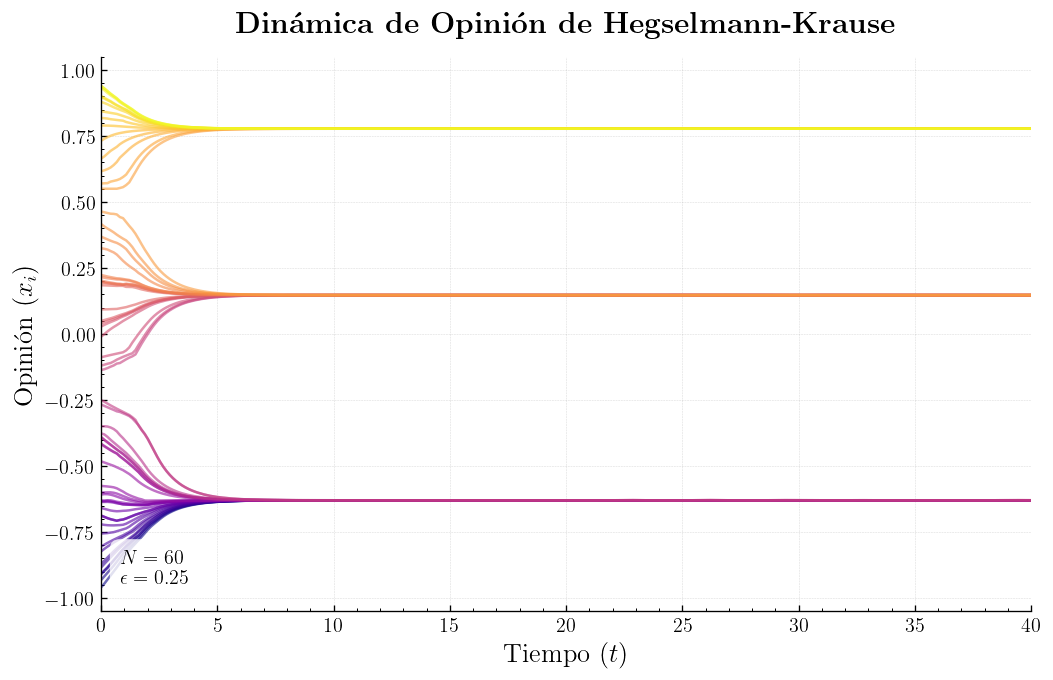

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ─── 1. DEFINICIÓN DEL SISTEMA DINÁMICO (HEGSELMANN-KRAUSE) ───────────────────
def hegselmann_krause(t, x, epsilon):
    """
    Calcula las derivadas dx/dt para el modelo de Hegselmann-Krause.
    x: Vector de opiniones de tamaño (N,)
    epsilon: Umbral de confianza estricto
    """
    N = len(x)

    # Truco de vectorización: Calculamos la matriz de diferencias de opiniones (N, N)
    # diff_matrix[i, j] = x[j] - x[i]
    diff_matrix = x[:, np.newaxis] - x[np.newaxis, :]

    # Calculamos las distancias absolutas
    distances = np.abs(diff_matrix)

    # Matriz de adyacencia social: 1 si están dentro del umbral epsilon, 0 si no.
    # Nota: Un agente siempre es vecino de sí mismo porque |x_i - x_i| = 0 < epsilon
    adjacency = (distances < epsilon).astype(float)

    # Cardinal de N_i(t): Cuenta cuántos vecinos válidos tiene cada agente 'i'
    # Sumamos por filas para obtener un vector de tamaño (N,)
    num_neighbors = np.sum(adjacency, axis=1)

    # Calculamos la sumatoria: \sum_{j \in N_i} (x_j - x_i)
    # Al multiplicar diff_matrix por la matriz de adyacencia (elemento a elemento),
    # anulamos las diferencias de los agentes que quedan fuera del umbral.
    interactions_sum = np.sum(-diff_matrix * adjacency, axis=1)

    # dx_i/dt = (1 / |N_i|) * sumatoria
    dxdt = interactions_sum / num_neighbors

    return dxdt

# ─── 2. CONFIGURACIÓN DE LA SIMULACIÓN ────────────────────────────────────────
np.random.seed(42)  # Semilla para que los resultados sean replicables

N = 60              # Número de agentes (individuos en la red social)
epsilon = 0.25      # Umbral de confianza (intenta cambiarlo a 0.15 o 0.45)
t_span = (0, 40)    # Intervalo de tiempo (t_inicio, t_final)
t_eval = np.linspace(t_span[0], t_span[1], 300)  # Puntos donde evaluaremos la solución

# Condiciones iniciales: opiniones distribuidas uniformemente en [-1, 1]
x0 = np.random.uniform(-1, 1, N)
x0.sort()  # Ordenarlos facilita ver el flujo y asignar colores estéticos

# ─── 3. SOLUCIÓN NUMÉRICA DE LA EDO ──────────────────────────────────────────
# Resolvemos usando RK45 (Runge-Kutta de orden 4 y 5)
sol = solve_ivp(
    fun=hegselmann_krause,
    t_span=t_span,
    y0=x0,
    t_eval=t_eval,
    args=(epsilon,),  # Pasamos epsilon como argumento a la función
    method='RK45'
)

# ─── 4. VISUALIZACIÓN DE LA DINÁMICA SOCIAL ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Creamos un mapa de colores basado en las opiniones iniciales para identificar a cada agente
colors = plt.cm.plasma(np.linspace(0, 1, N))

# Graficamos la trayectoria de opinión de cada agente a lo largo del tiempo
for i in range(N):
    ax.plot(sol.t, sol.y[i], color=colors[i], alpha=0.6, linewidth=1.5)

# Títulos y etiquetas usando LaTeX (respetando los rcParams de tu notebook)
ax.set_title(r'\textbf{Dinámica de Opinión de Hegselmann-Krause}', pad=15)
ax.set_xlabel(r'Tiempo ($t$)')
ax.set_ylabel(r'Opinión ($x_i$)')

# Límites lógicos del modelo
ax.set_ylim(-1.05, 1.05)
ax.set_xlim(t_span[0], t_span[1])

# Añadimos una sutil cuadrícula y un cuadro de texto informativo
ax.grid(True)
info_text = f'$N = {N}$\n$\\epsilon = {epsilon}$'
ax.text(0.02, 0.05, info_text, transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='none'))

plt.show()